# Stage 3 — DINOv2 Selective Temporal Token Reuse

This notebook is the **Stage 3 prototype** following the Stage 2 temporal-redundancy experiment.

### Objective
Use the previous frame as a cache and **recompute only changed patch tokens**, while reusing stable patch representations.

### Important scientific distinction
Stage 2 measured whether tokens are similar. Stage 3 tests an actual selective-recomputation prototype.

This implementation uses a **reduced-token transformer approximation**:
- first frame: full DINOv2 forward
- next frame: detect changed image patches
- forward only `CLS + changed patch tokens`
- reuse previous patch tokens at stable positions
- compare the reconstructed representation with a full DINOv2 forward

This is an experimental prototype, not a claim that standard DINOv2 can be losslessly token-pruned. Global self-attention means stable tokens can still be affected by changed tokens.


## Kaggle Input — only WoodScape is required

Upload your WoodScape dataset:

```text
/kaggle/input/datasets/saanvishetty0804/car-nvidia/
├── rgb_images-001/
│   └── rgb_images/
└── previous_images-001/
    └── previous_images/
```

You **do not need** UnifiedPerception for this notebook. Stage 3 works directly with the Hugging Face DINOv2 backbone and individual WoodScape PNG frames.

You also do **not** need:
- Stage 1 results
- Stage 2 CSV/JSON results
- `woodscape_results_clean`
- annotated videos
- calibration folders

The notebook downloads `facebook/dinov2-small` from Hugging Face into `/kaggle/working/huggingface_cache`.


In [1]:
from pathlib import Path
import os, sys, json, time, shutil, zipfile, warnings, re
warnings.filterwarnings("ignore")

DATA_ROOT = Path("/kaggle/input/datasets/saanvishetty0804/car-nvidia")
CURRENT_DIR = DATA_ROOT / "rgb_images-001" / "rgb_images"
PREVIOUS_DIR = DATA_ROOT / "previous_images-001" / "previous_images"

assert CURRENT_DIR.exists(), f"Missing {CURRENT_DIR}"
assert PREVIOUS_DIR.exists(), f"Missing {PREVIOUS_DIR}"

OUT = Path("/kaggle/working/stage3_token_reuse")
OUT.mkdir(parents=True, exist_ok=True)

print("WoodScape:", DATA_ROOT)
print("Current:", CURRENT_DIR)
print("Previous:", PREVIOUS_DIR)
print("Output:", OUT)


WoodScape: /kaggle/input/datasets/saanvishetty0804/car-nvidia
Current: /kaggle/input/datasets/saanvishetty0804/car-nvidia/rgb_images-001/rgb_images
Previous: /kaggle/input/datasets/saanvishetty0804/car-nvidia/previous_images-001/previous_images
Output: /kaggle/working/stage3_token_reuse


In [2]:
import torch, numpy as np, pandas as pd
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), "Enable a Kaggle GPU."
DEVICE = torch.device("cuda")
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
GPU: Tesla T4


## Configuration

For the first successful run, use **8 pairs per camera**. After validating the notebook, increase to 32 or 64.

The default change detector is image-space patch difference. This is intentionally lightweight: it avoids running DINOv2 just to decide which tokens changed.


In [34]:
MODEL_ID = "facebook/dinov2-small"
IMAGE_SIZE = 640
PATCH_SIZE = 14
GRID = 45
NUM_PATCHES = GRID * GRID
DIM = 384

CAMERAS = ["FV", "RV", "MVL", "MVR"]

PAIRS_PER_CAMERA = 32

# Image-space change threshold. Lower => more changed tokens.
PIXEL_DIFF_THRESHOLD = 0.08

# Optional Stage-2-inspired candidate threshold for reporting only.
COSINE_REFERENCE = 0.95

print("Model:", MODEL_ID)
print("Resolution:", IMAGE_SIZE)
print("Patch grid:", GRID, "x", GRID)
print("Patch tokens:", NUM_PATCHES)
print("Embedding dimension:", DIM)
print("Pairs/camera:", PAIRS_PER_CAMERA)
print("Pixel patch threshold:", PIXEL_DIFF_THRESHOLD)


Model: facebook/dinov2-small
Resolution: 640
Patch grid: 45 x 45
Patch tokens: 2025
Embedding dimension: 384
Pairs/camera: 32
Pixel patch threshold: 0.08


In [35]:
# Robust current/previous pairing.
def parse_name(path):
    m = re.match(r"^(\d+)_([A-Za-z0-9]+)(?:_prev)?\.png$", path.name)
    if not m:
        return None, None
    return int(m.group(1)), m.group(2)

previous_lookup = {}
for p in PREVIOUS_DIR.glob("*.png"):
    fid, cam = parse_name(p)
    if fid is not None and cam in CAMERAS:
        previous_lookup[(cam, fid)] = p

pairs = {c: [] for c in CAMERAS}

for p in CURRENT_DIR.glob("*.png"):
    fid, cam = parse_name(p)
    if fid is None or cam not in CAMERAS:
        continue
    prev = previous_lookup.get((cam, fid))
    if prev is not None:
        pairs[cam].append({
            "camera": cam,
            "frame_id": fid,
            "current": p,
            "previous": prev,
        })

for c in CAMERAS:
    pairs[c].sort(key=lambda x: x["frame_id"])
    print(c, len(pairs[c]), "pairs")

assert all(len(pairs[c]) > 0 for c in CAMERAS)


FV 2037 pairs
RV 1986 pairs
MVL 2066 pairs
MVR 2145 pairs


## Load DINOv2 directly

We use Hugging Face directly here rather than the professor's video-oriented `extract_features()` function. WoodScape stores individual PNG frames, and the direct image path avoids the `decord` video-reader issue that can occur when a PNG is passed to a video reader.

At 640×640, DINOv2 ViT-S/14 produces 2025 patch tokens.


In [36]:
HF_CACHE = Path("/kaggle/working/huggingface_cache")
HF_CACHE.mkdir(parents=True, exist_ok=True)

from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained(
    MODEL_ID,
    cache_dir=str(HF_CACHE),
    use_fast=False,
)

model = AutoModel.from_pretrained(
    MODEL_ID,
    cache_dir=str(HF_CACHE),
    output_hidden_states=True,
).to(DEVICE).eval()

for p in model.parameters():
    p.requires_grad = False

print("DINOv2 loaded.")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded.


In [37]:
def load_image_tensor(path):
    image = Image.open(path).convert("RGB").resize(
        (IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BICUBIC
    )
    x = processor(
        images=image,
        return_tensors="pt",
        do_resize=False,
        do_center_crop=False,
    )["pixel_values"]
    assert tuple(x.shape) == (1, 3, IMAGE_SIZE, IMAGE_SIZE)
    return x.to(DEVICE)

@torch.inference_mode()
def full_forward(path):
    x = load_image_tensor(path)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    out = model(pixel_values=x)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    return out, elapsed

# Smoke test.
smoke, smoke_time = full_forward(pairs["FV"][0]["current"])
assert tuple(smoke.last_hidden_state.shape) == (1, 2026, 384)
print("Smoke test PASSED")
print("Runtime:", round(smoke_time, 4), "s")
print("Tokens:", tuple(smoke.last_hidden_state.shape))


Smoke test PASSED
Runtime: 0.1073 s
Tokens: (1, 2026, 384)


## Lightweight image-space change detector

Each 640×640 image is divided into the same 45×45 patch grid used by DINOv2.

For each patch, calculate mean absolute RGB difference between current and previous images.

Stable patch:
`mean_pixel_difference < threshold`

Changed patch:
`mean_pixel_difference >= threshold`


In [38]:
def image_patch_change_mask(current_path, previous_path, threshold=PIXEL_DIFF_THRESHOLD):
    a = np.asarray(
        Image.open(current_path).convert("RGB").resize(
            (IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BICUBIC
        ),
        dtype=np.float32,
    ) / 255.0
    b = np.asarray(
        Image.open(previous_path).convert("RGB").resize(
            (IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BICUBIC
        ),
        dtype=np.float32,
    ) / 255.0

    diff = np.abs(a - b).mean(axis=2)

    # Crop to 45*14 = 630 pixels; DINOv2 uses 14x14 patches.
    diff = diff[:GRID*PATCH_SIZE, :GRID*PATCH_SIZE]

    patch_diff = diff.reshape(
        GRID, PATCH_SIZE, GRID, PATCH_SIZE
    ).mean(axis=(1, 3))

    mask = patch_diff >= threshold
    return mask.reshape(-1), patch_diff

mask, patch_diff = image_patch_change_mask(
    pairs["FV"][0]["current"],
    pairs["FV"][0]["previous"],
)

print("Changed:", int(mask.sum()), "/", NUM_PATCHES)
print("Stable :", int((~mask).sum()), "/", NUM_PATCHES)
print("Changed %:", round(mask.mean()*100, 2))


Changed: 655 / 2025
Stable : 1370 / 2025
Changed %: 32.35


## Reduced-token Stage 3 forward

The first frame is fully encoded.

For the next frame, only:
- CLS
- changed patch tokens

are sent through the DINOv2 transformer encoder.

Stable patch tokens are copied from the previous representation.

This gives a **real reduced sequence length** to the transformer. It is therefore a computation-saving prototype, although its representation is only an approximation to full DINOv2 because global attention has been restricted to the selected sequence.


In [39]:
# Locate the HF DINOv2 embedding + encoder modules robustly.
print("Model class:", type(model).__name__)
print("Top-level modules:")
print([n for n, _ in model.named_children()])


Model class: Dinov2Model
Top-level modules:
['embeddings', 'encoder', 'layernorm']


In [40]:
# DINOv2 HF implementations normally expose embeddings and encoder.
assert hasattr(model, "embeddings"), "Unexpected DINOv2 model: no embeddings module."
assert hasattr(model, "encoder"), "Unexpected DINOv2 model: no encoder module."

print("Embeddings:", type(model.embeddings).__name__)
print("Encoder:", type(model.encoder).__name__)
print("Encoder children:", [n for n, _ in model.encoder.named_children()])


Embeddings: Dinov2Embeddings
Encoder: Dinov2Encoder
Encoder children: ['layer']


In [41]:
def get_patch_embeddings(path):
    x = load_image_tensor(path)
    with torch.inference_mode():
        emb = model.embeddings(x)
    # Expected: [1, 2026, 384]
    assert emb.ndim == 3 and emb.shape[1] == 2026 and emb.shape[2] == 384
    return emb

def get_encoder_layers():
    if hasattr(model.encoder, "layer"):
        return model.encoder.layer
    if hasattr(model.encoder, "layers"):
        return model.encoder.layers
    raise AttributeError("Could not locate encoder layers.")

layers = get_encoder_layers()
print("Number of transformer layers:", len(layers))


Number of transformer layers: 12


### Compatibility wrapper

Hugging Face DINOv2 versions differ slightly in how encoder layers are called. The wrapper below first tries the normal keyword-based call and then a positional call.

If your installed Transformers version exposes an unexpected signature, this cell prints the signature rather than silently producing an incorrect result.


In [42]:
import inspect

def run_layer(layer, hidden_states):
    # Common HF ViT/DINOv2 form.
    try:
        result = layer(hidden_states=hidden_states)
    except TypeError:
        try:
            result = layer(hidden_states)
        except Exception as e:
            print("Layer signature:", inspect.signature(layer.forward))
            raise e

    if isinstance(result, tuple):
        return result[0]
    if hasattr(result, "last_hidden_state"):
        return result.last_hidden_state
    if hasattr(result, "hidden_states"):
        return result.hidden_states
    return result

# Verify one layer on the full embedded sequence.
with torch.inference_mode():
    z = get_patch_embeddings(pairs["FV"][0]["previous"])
    z1 = run_layer(layers[0], z)

print("Layer smoke shape:", tuple(z1.shape))
assert z1.shape == z.shape
print("Encoder-layer smoke test PASSED.")


Layer smoke shape: (1, 2026, 384)
Encoder-layer smoke test PASSED.


## Stage 3 selective prototype

For every layer we retain a full previous hidden-state cache.

For the current frame:
1. start from current patch embeddings for changed positions
2. keep previous hidden states for stable positions
3. run the transformer only on `CLS + changed patches`
4. scatter the changed outputs back into the 2026-token grid
5. reuse previous outputs for stable patches

Because the reduced sequence omits stable tokens from attention, this is an **approximate selective-recomputation architecture**. We explicitly measure its fidelity against a full current-frame DINOv2 forward.


In [43]:
def reduced_encoder_forward(current_path, previous_cache, changed_mask):
    """
    Experimental reduced-token forward.

    The timing includes current-frame embedding preparation plus the
    reduced transformer path.
    """
    torch.cuda.synchronize()
    t0 = time.perf_counter()

    current_emb = get_patch_embeddings(current_path)  # [1, 2026, 384]

    changed_idx = torch.nonzero(
        torch.as_tensor(changed_mask, device=DEVICE),
        as_tuple=False
    ).flatten() + 1

    selected_idx = torch.cat([
        torch.zeros(1, dtype=torch.long, device=DEVICE),
        changed_idx
    ])

    h = current_emb[:, selected_idx, :]

    for layer in layers:
        h = run_layer(layer, h)

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    reconstructed = previous_cache[-1].clone()
    reconstructed[:, selected_idx, :] = h

    return reconstructed, elapsed, int(len(selected_idx))


In [44]:
def build_previous_cache(path):
    """
    Full first-frame forward. Returns every transformer-layer hidden state.
    """
    emb = get_patch_embeddings(path)
    cache = [emb.detach()]

    h = emb
    with torch.inference_mode():
        for layer in layers:
            h = run_layer(layer, h)
            cache.append(h.detach())

    return cache


## Run Stage 3 experiment

We compare:

**Baseline**
- full DINOv2 current-frame forward

**Temporal reuse**
- first frame is full
- subsequent current frame uses reduced-token sequence

Metrics:
- changed-token percentage
- reused-token percentage
- full DINOv2 latency
- selective transformer latency
- speedup of the transformer portion
- final-token cosine similarity
- final-token relative L2 error

The latency comparison is reported carefully because the prototype still has Python-side indexing/scattering overhead.


In [45]:
def representation_metrics(full_hidden, reused_hidden):
    a = full_hidden[:, 1:, :].float()
    b = reused_hidden[:, 1:, :].float()

    cos = F.cosine_similarity(a, b, dim=-1)
    rel_l2 = torch.linalg.vector_norm(a-b, dim=-1) / (
        torch.linalg.vector_norm(a, dim=-1).clamp_min(1e-8)
    )

    return {
        "mean_patch_cosine": float(cos.mean().cpu()),
        "median_patch_cosine": float(cos.median().cpu()),
        "mean_relative_l2": float(rel_l2.mean().cpu()),
        "median_relative_l2": float(rel_l2.median().cpu()),
    }


In [46]:
results = []

for camera in CAMERAS:
    selected = pairs[camera][:PAIRS_PER_CAMERA]
    if not selected:
        continue

    previous_cache = None
    previous_current_path = None

    for j, item in enumerate(selected):
        print(f"{camera}: {j+1}/{len(selected)} frame {item['frame_id']}")

        # Full current-frame baseline.
        full_out, full_time = full_forward(item["current"])
        full_hidden = full_out.last_hidden_state.detach()

        if previous_cache is None:
            # First frame establishes the temporal cache.
            # No reuse is possible yet.
            results.append({
                "camera": camera,
                "frame_id": item["frame_id"],
                "mode": "initial_full",
                "changed_percent": 100.0,
                "reused_percent": 0.0,
                "full_dinov2_seconds": full_time,
                "selective_total_seconds": full_time,
                "selected_tokens": 2026,
                "transformer_token_fraction": 1.0,
                "mean_patch_cosine": 1.0,
                "median_patch_cosine": 1.0,
                "mean_relative_l2": 0.0,
                "median_relative_l2": 0.0,
            })

            # Cache this processed frame for the next frame.
            previous_cache = build_previous_cache(item["current"])
            previous_current_path = item["current"]
            continue

        # Lightweight current-vs-previous image change detector.
        mask, _ = image_patch_change_mask(
            item["current"], item["previous"]
        )

        reused_hidden, selective_time, selected_tokens = reduced_encoder_forward(
            item["current"], previous_cache, mask
        )

        metrics = representation_metrics(full_hidden, reused_hidden)

        changed_pct = float(mask.mean() * 100)
        reused_pct = 100.0 - changed_pct

        results.append({
            "camera": camera,
            "frame_id": item["frame_id"],
            "mode": "temporal_reuse",
            "changed_percent": changed_pct,
            "reused_percent": reused_pct,
            "full_dinov2_seconds": full_time,
            "selective_total_seconds": selective_time,
            "selected_tokens": selected_tokens,
            "transformer_token_fraction": selected_tokens / 2026.0,
            **metrics,
        })

        # In streaming use, the current full frame becomes the next cache.
        # We compute this full cache only to make the notebook's sequential
        # experiment explicit and reproducible. In deployment, it is already
        # available from the preceding accepted frame.
        previous_cache = build_previous_cache(item["current"])
        previous_current_path = item["current"]

df = pd.DataFrame(results)
df.to_csv(OUT / "stage3_token_reuse_results.csv", index=False)
display(df)


FV: 1/32 frame 0
FV: 2/32 frame 1
FV: 3/32 frame 2
FV: 4/32 frame 3
FV: 5/32 frame 4
FV: 6/32 frame 5
FV: 7/32 frame 6
FV: 8/32 frame 7
FV: 9/32 frame 8
FV: 10/32 frame 9
FV: 11/32 frame 10
FV: 12/32 frame 11
FV: 13/32 frame 12
FV: 14/32 frame 13
FV: 15/32 frame 14
FV: 16/32 frame 15
FV: 17/32 frame 16
FV: 18/32 frame 17
FV: 19/32 frame 18
FV: 20/32 frame 19
FV: 21/32 frame 20
FV: 22/32 frame 21
FV: 23/32 frame 22
FV: 24/32 frame 23
FV: 25/32 frame 24
FV: 26/32 frame 25
FV: 27/32 frame 26
FV: 28/32 frame 27
FV: 29/32 frame 33
FV: 30/32 frame 34
FV: 31/32 frame 37
FV: 32/32 frame 39
RV: 1/32 frame 28
RV: 2/32 frame 29
RV: 3/32 frame 30
RV: 4/32 frame 31
RV: 5/32 frame 32
RV: 6/32 frame 35
RV: 7/32 frame 36
RV: 8/32 frame 38
RV: 9/32 frame 48
RV: 10/32 frame 49
RV: 11/32 frame 50
RV: 12/32 frame 51
RV: 13/32 frame 52
RV: 14/32 frame 57
RV: 15/32 frame 58
RV: 16/32 frame 63
RV: 17/32 frame 64
RV: 18/32 frame 67
RV: 19/32 frame 72
RV: 20/32 frame 73
RV: 21/32 frame 78
RV: 22/32 frame 79
RV

,camera,frame_id,mode,changed_percent,reused_percent,full_dinov2_seconds,selective_total_seconds,selected_tokens,transformer_token_fraction,mean_patch_cosine,median_patch_cosine,mean_relative_l2,median_relative_l2
0,FV,0,initial_full,100.000000,0.000000,0.106906,0.106906,2026,1.000000,1.000000,1.000000,0.000000,0.000000
1,FV,1,temporal_reuse,32.740741,67.259259,0.068603,0.077678,664,0.327739,0.708652,0.761385,0.770758,0.751956
2,FV,2,temporal_reuse,23.802469,76.197531,0.065283,0.073127,483,0.238401,0.660501,0.719702,0.795210,0.773694
3,FV,3,temporal_reuse,27.950617,72.049383,0.067069,0.073368,567,0.279862,0.713954,0.775913,0.769985,0.745688
4,FV,4,temporal_reuse,22.814815,77.185185,0.066843,0.070004,463,0.228529,0.647470,0.713214,0.799243,0.777695
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,MVR,120,temporal_reuse,9.037037,90.962963,0.065058,0.074888,184,0.090819,0.605730,0.652563,0.813774,0.798166
124,MVR,121,temporal_reuse,24.493827,75.506173,0.066077,0.074743,497,0.245311,0.648015,0.688376,0.793515,0.779950
125,MVR,129,temporal_reuse,17.530864,82.469136,0.063148,0.077315,356,0.175716,0.620266,0.646246,0.808319,0.802558
126,MVR,146,temporal_reuse,18.370370,81.629630,0.064246,0.078330,373,0.184107,0.643312,0.673153,0.792039,0.783134


## Summary

This table is the main Stage 3 backbone result.

Do **not** interpret `reused_percent` as speedup.

The measured timing compares a full current-frame DINOv2 forward with the reduced-token prototype (image preprocessing + reduced transformer path). The prototype also has cache-maintenance overhead, so report the measured result as a prototype benchmark rather than a guaranteed deployment speedup.


In [47]:
summary = (
    df[df["mode"] == "temporal_reuse"]
    .groupby("camera")
    .agg(
        frames=("frame_id", "count"),
        mean_reused_percent=("reused_percent", "mean"),
        mean_changed_percent=("changed_percent", "mean"),
        mean_selected_tokens=("selected_tokens", "mean"),
        mean_token_fraction=("transformer_token_fraction", "mean"),
        mean_full_time=("full_dinov2_seconds", "mean"),
        mean_selective_time=("selective_total_seconds", "mean"),
        mean_cosine=("mean_patch_cosine", "mean"),
        median_cosine=("median_patch_cosine", "mean"),
        mean_relative_l2=("mean_relative_l2", "mean"),
    )
    .reset_index()
)

summary["transformer_time_speedup"] = (
    summary["mean_full_time"] /
    summary["mean_selective_time"]
)

summary["theoretical_token_reduction_percent"] = (
    1.0 - summary["mean_token_fraction"]
) * 100.0

display(summary)
summary.to_csv(OUT / "stage3_summary.csv", index=False)


,camera,frames,mean_reused_percent,mean_changed_percent,mean_selected_tokens,mean_token_fraction,mean_full_time,mean_selective_time,mean_cosine,median_cosine,mean_relative_l2,transformer_time_speedup,theoretical_token_reduction_percent
0,FV,31,71.632019,28.367981,575.451613,0.284033,0.068067,0.077968,0.678113,0.736162,0.785536,0.873006,71.596663
1,MVL,31,72.538431,27.461569,557.096774,0.274974,0.064393,0.075338,0.657016,0.699615,0.782496,0.854715,72.502627
2,MVR,31,77.354042,22.645958,459.580645,0.226841,0.064033,0.076783,0.660057,0.700844,0.783578,0.833941,77.315862
3,RV,31,77.577061,22.422939,455.064516,0.224612,0.068413,0.073976,0.703841,0.764445,0.764268,0.924807,77.538770


In [48]:
# Overall result.
overall = (
    df[df["mode"] == "temporal_reuse"]
    .agg({
        "reused_percent": "mean",
        "changed_percent": "mean",
        "selected_tokens": "mean",
        "transformer_token_fraction": "mean",
        "full_dinov2_seconds": "mean",
        "selective_total_seconds": "mean",
        "mean_patch_cosine": "mean",
        "median_patch_cosine": "mean",
        "mean_relative_l2": "mean",
        "median_relative_l2": "mean",
    })
)

overall_speedup = (
    overall["full_dinov2_seconds"] /
    overall["selective_total_seconds"]
)

print("STAGE 3 OVERALL")
print("=" * 60)
print("Mean reused tokens       :", round(float(overall["reused_percent"]), 2), "%")
print("Mean changed tokens      :", round(float(overall["changed_percent"]), 2), "%")
print("Mean selected tokens     :", round(float(overall["selected_tokens"]), 1), "/ 2026")
print("Token fraction processed :", round(float(overall["transformer_token_fraction"]), 4))
print("Full forward time        :", round(float(overall["full_dinov2_seconds"]), 4), "s")
print("Selective path time      :", round(float(overall["selective_total_seconds"]), 4), "s")
print("Prototype time ratio     :", round(float(overall_speedup), 3), "x")
print("Mean final patch cosine  :", round(float(overall["mean_patch_cosine"]), 6))
print("Mean relative L2 error   :", round(float(overall["mean_relative_l2"]), 6))


STAGE 3 OVERALL
Mean reused tokens       : 74.78 %
Mean changed tokens      : 25.22 %
Mean selected tokens     : 511.8 / 2026
Token fraction processed : 0.2526
Full forward time        : 0.0662 s
Selective path time      : 0.076 s
Prototype time ratio     : 0.871 x
Mean final patch cosine  : 0.674757
Mean relative L2 error   : 0.77897


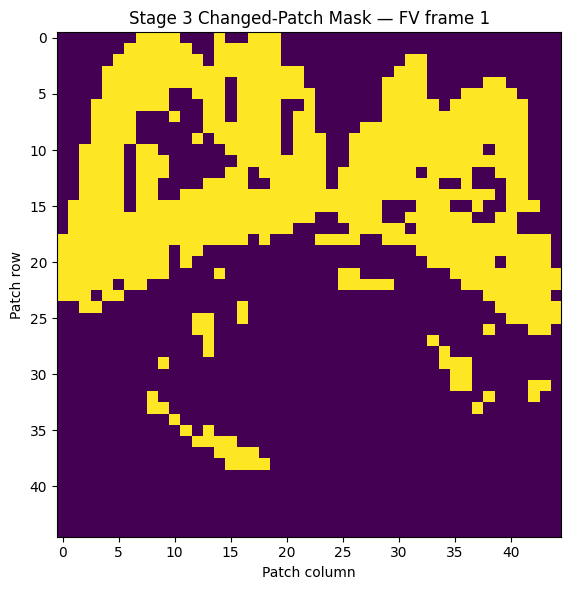

In [49]:
# Visualize one representative frame.
row = df[df["mode"] == "temporal_reuse"].iloc[0]
cam = row["camera"]
fid = int(row["frame_id"])
item = next(x for x in pairs[cam] if x["frame_id"] == fid)

mask, patch_diff = image_patch_change_mask(
    item["current"], item["previous"]
)

plt.figure(figsize=(7, 6))
plt.imshow(mask.reshape(GRID, GRID))
plt.title(f"Stage 3 Changed-Patch Mask — {cam} frame {fid}")
plt.xlabel("Patch column")
plt.ylabel("Patch row")
plt.tight_layout()
plt.savefig(OUT / "changed_patch_mask.png", dpi=150)
plt.show()


## Optional threshold sweep

Run this after the main experiment works.

This tests whether changing the lightweight detector threshold changes the reuse/changed-token ratio. It does not require rerunning DINOv2 for every threshold.


,pixel_diff_threshold,mean_potential_reuse_percent,median_potential_reuse_percent
0,0.04,58.868827,57.802469
1,0.06,68.278935,67.555556
2,0.08,74.758873,75.259259
3,0.10,79.574846,80.345679
4,0.15,87.880401,88.913580


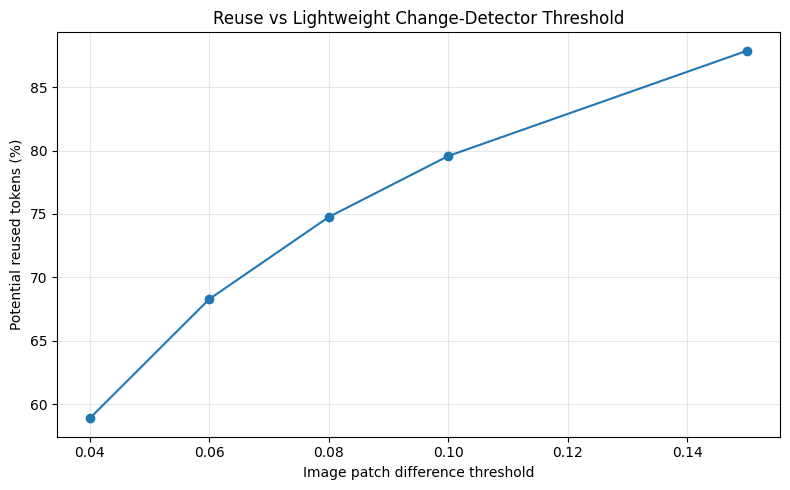

In [50]:
thresholds = [0.04, 0.06, 0.08, 0.10, 0.15]
sweep_rows = []

for threshold in thresholds:
    vals = []
    for camera in CAMERAS:
        for item in pairs[camera][:PAIRS_PER_CAMERA]:
            mask, _ = image_patch_change_mask(
                item["current"], item["previous"], threshold
            )
            vals.append(float((~mask).mean() * 100))

    sweep_rows.append({
        "pixel_diff_threshold": threshold,
        "mean_potential_reuse_percent": np.mean(vals),
        "median_potential_reuse_percent": np.median(vals),
    })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)
sweep_df.to_csv(OUT / "stage3_threshold_sweep.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(
    sweep_df["pixel_diff_threshold"],
    sweep_df["mean_potential_reuse_percent"],
    marker="o",
)
plt.xlabel("Image patch difference threshold")
plt.ylabel("Potential reused tokens (%)")
plt.title("Reuse vs Lightweight Change-Detector Threshold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "threshold_sweep.png", dpi=150)
plt.show()


In [51]:
# Save a machine-readable Stage 3 report.
report = {
    "stage": "Stage 3 - Selective Temporal Token Reuse Backbone Prototype",
    "dataset": "WoodScape",
    "model": "DINOv2 ViT-S/14",
    "model_id": MODEL_ID,
    "resolution": "640x640",
    "patch_grid": "45x45",
    "patch_tokens": 2025,
    "embedding_dimension": 384,
    "cameras": CAMERAS,
    "pairs_per_camera": PAIRS_PER_CAMERA,
    "change_detector": "mean absolute RGB difference per 14x14 patch",
    "pixel_diff_threshold": PIXEL_DIFF_THRESHOLD,
    "stage2_reference_cosine": COSINE_REFERENCE,
    "method": (
        "First frame full DINOv2; subsequent frame uses CLS + changed "
        "patch tokens through the transformer and reuses previous "
        "representations for stable patch positions."
    ),
    "downstream_heads": "Not run in this backbone-only prototype; detection/action integration should use the reconstructed features in the next evaluation step.",
    "important_limitation": (
        "This is a reduced-token approximation to global DINOv2 attention. "
        "Stable tokens are not recomputed even though global attention can "
        "allow changed tokens to influence them."
    ),
    "outputs": [
        "stage3_token_reuse_results.csv",
        "stage3_summary.csv",
        "stage3_threshold_sweep.csv",
        "changed_patch_mask.png",
        "threshold_sweep.png",
    ],
}

with open(OUT / "stage3_summary.json", "w") as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))
print("\n" + "=" * 70)
print("STAGE 3 COMPLETE")
print("=" * 70)
print("Results saved to:", OUT)


{
  "stage": "Stage 3 - Selective Temporal Token Reuse Backbone Prototype",
  "dataset": "WoodScape",
  "model": "DINOv2 ViT-S/14",
  "model_id": "facebook/dinov2-small",
  "resolution": "640x640",
  "patch_grid": "45x45",
  "patch_tokens": 2025,
  "embedding_dimension": 384,
  "cameras": [
    "FV",
    "RV",
    "MVL",
    "MVR"
  ],
  "pairs_per_camera": 32,
  "change_detector": "mean absolute RGB difference per 14x14 patch",
  "pixel_diff_threshold": 0.08,
  "stage2_reference_cosine": 0.95,
  "method": "First frame full DINOv2; subsequent frame uses CLS + changed patch tokens through the transformer and reuses previous representations for stable patch positions.",
  "downstream_heads": "Not run in this backbone-only prototype; detection/action integration should use the reconstructed features in the next evaluation step.",
  "important_limitation": "This is a reduced-token approximation to global DINOv2 attention. Stable tokens are not recomputed even though global attention can al

In [53]:
# ZIP all Stage 3 results for download
import shutil
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/stage3_token_reuse")
ZIP_PATH = Path("/kaggle/working/stage3_token_reuse_32pairs")

shutil.make_archive(
    str(ZIP_PATH),
    "zip",
    root_dir=OUTPUT_DIR
)

print("ZIP created:")
print(ZIP_PATH.with_suffix(".zip"))
print(f"Size: {ZIP_PATH.with_suffix('.zip').stat().st_size / (1024**2):.2f} MB")

ZIP created:
/kaggle/working/stage3_token_reuse_32pairs.zip
Size: 0.08 MB
